# Epic vs. Tragedy — better comparisons

In [1]:
import numpy as np
import pandas as pd

homer_df = pd.read_parquet("../parquet/homer_dtm.parquet")
tragedy_df = pd.read_parquet("../parquet/tragedy-with-years_dtm.parquet")

In [2]:
homer_series = homer_df["iliad"] + homer_df["odyssey"]
tragedy_series = tragedy_df.sum(axis=1)

homer_series, tragedy_series = homer_series.align(tragedy_series, fill_value=0)

total_homer = homer_series.sum()
total_tragedy = tragedy_series.sum()

# apply Laplace smoothing
V = len(homer_series)
alpha = 1
p_epic = (homer_series + alpha) / (total_homer + alpha * V)
p_tragedy = (tragedy_series + alpha) / (total_tragedy + alpha * V)
log_ratio = np.log(p_epic / p_tragedy)

In [3]:
log_ratio.sort_values().to_csv("../csv/epic_tragedy_log_ratio.csv")

In [4]:
tragedy_aligned = tragedy_df.reindex(log_ratio.index, fill_value=0)
speaker_score = tragedy_aligned.multiply(log_ratio, axis=0).sum(axis=0) / tragedy_df.sum(axis=0)

In [5]:
speaker_score.name = "epicness"
speaker_df = speaker_score.reset_index()

In [6]:
speaker_df["token_count"] = tragedy_aligned.sum(axis=0).values

In [7]:
play_df = speaker_df.groupby(["dramatist", "title"]).apply(
    lambda g: (g["epicness"] * g["token_count"]).sum() / g["token_count"].sum()).reset_index().rename(
        columns={0: "epicness"}
    )

In [8]:
import altair as alt

alt.Chart(play_df).mark_point().encode(
    x="epicness:Q",
    y=alt.Y("dramatist:N", sort=["Aeschylus", "Sophocles", "Euripides"]),
    color=alt.Color("dramatist:N", sort=["Aeschylus", "Sophocles", "Euripides"]),
    tooltip=["dramatist:N", "title:N", "epicness:Q"],
).properties(title="Epicness by play and dramatist")

alt.Chart(...)

In [9]:
speaker_df["label"] = speaker_df["dramatist"] + " – " + speaker_df["title"] + " – " + speaker_df["speaker"]

filtered_speaker_df = speaker_df[speaker_df["token_count"] >= 50]
speaker_df_viz = pd.concat([filtered_speaker_df.nsmallest(20, "epicness"), filtered_speaker_df.nlargest(20, "epicness")])
alt.Chart(speaker_df_viz).mark_point().encode(
    x="epicness:Q",
    y=alt.Y("label:N", sort="x", axis=alt.Axis(labelLimit=400)),
    color=alt.Color("dramatist:N", sort=["Aeschylus", "Sophocles", "Euripides"]),
    tooltip=["speaker:N", "dramatist:N", "title:N", "epicness:Q"],
).properties(title="Epicness by speaker and play", width=400)

alt.Chart(...)

## Normality of epicness scores by speaker

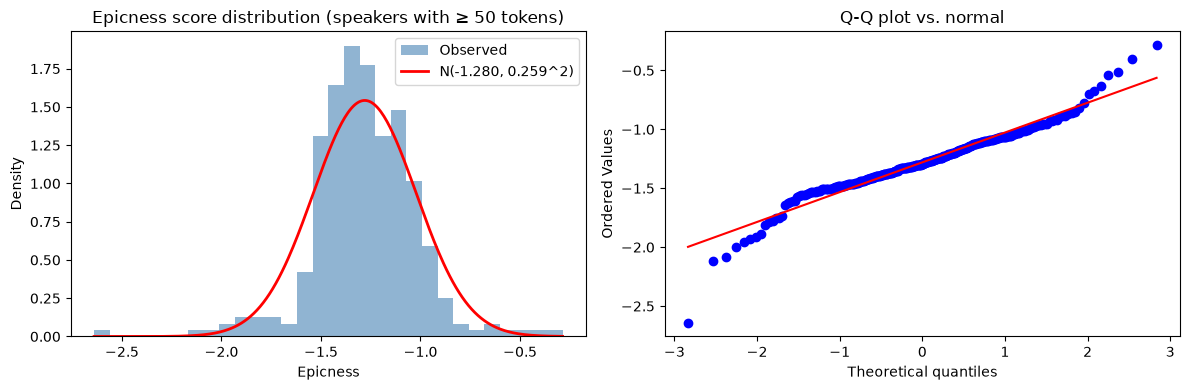

In [10]:
import matplotlib.pyplot as plt
import scipy.stats as stats

scores = speaker_df["epicness"].dropna()
mu, sigma = scores.mean(), scores.std()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(scores, bins=30, density=True, alpha=0.6, color="steelblue", label="Observed")
x = np.linspace(scores.min(), scores.max(), 300)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), "r-", lw=2, label=f"N({mu:.3f}, {sigma:.3f}^2)")
axes[0].set_title("Epicness score distribution (speakers with ≥ 50 tokens)")
axes[0].set_xlabel("Epicness")
axes[0].set_ylabel("Density")
axes[0].legend()

stats.probplot(scores, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot vs. normal")

plt.tight_layout()
plt.show()

In [11]:
stat, p = stats.shapiro(scores)

print(f"p = {p:.4f}")

p = 0.0000


In [12]:
speaker_df.to_parquet("../parquet/epicness_by_speaker.parquet")
log_ratio.name = "epicness"
log_ratio.reset_index().to_parquet("../parquet/epicness_log_ratio.parquet")

In [13]:
line_epicness_df = pd.read_parquet("../parquet/tragedy_line_epicness.parquet")

line_epicness_df["heat"] = line_epicness_df["line_epicness"]

# Per-tragedy aggregate: mean of the per-line scores
tragedy_heat = (
    line_epicness_df.groupby(["dramatist", "title"])["line_epicness"]
    .mean()
    .sort_values()
)
line_epicness_df["line_urn"] = line_epicness_df["urn"] + ":" + line_epicness_df["n"].astype(str)
line_epicness_df["heat_scaled"] = line_epicness_df["heat"] / line_epicness_df["heat"].abs().max() * 10
line_epicness_df[["line_urn", "heat", "heat_scaled"]].sort_values(by="heat", ascending=True).to_csv("../csv/tragedy_urn_heat.csv")

# Tragedy: More like epic speech or epic narrative?

In [14]:
speech_narrative_df = pd.read_parquet("../parquet/homer_speech_narrative.parquet")
narrative_dtm = speech_narrative_df.iliad["narrative"] + speech_narrative_df.odyssey["narrative"]
speech_dtm = speech_narrative_df.iliad["speech"] + speech_narrative_df.odyssey["speech"]

narrative_dtm, speech_dtm = narrative_dtm.align(speech_dtm, fill_value=0)
total_narrative, total_speech = narrative_dtm.sum(), speech_dtm.sum()

V = len(narrative_dtm)
alpha = 1
p_narrative = (narrative_dtm + alpha) / (total_narrative + alpha * V)
p_speech = (speech_dtm + alpha) / (total_speech + alpha * V)
register_log_ratio = np.log(p_speech / p_narrative)  # + = speech-like, - = narrative-like

tragedy_reg_aligned = tragedy_df.reindex(register_log_ratio.index, fill_value=0)
speaker_register_score = (
    tragedy_reg_aligned.multiply(register_log_ratio, axis=0).sum(axis=0)
    / tragedy_df.sum(axis=0)
)
speaker_register_score.name = "speechiness"

In [15]:
speaker_register_score

dramatist  title       speaker     
Aeschylus  Agamemnon   Αἴγισθος        0.192331
                       Κασάνδρα        0.229698
                       Κλυταιμήστρα    0.214330
                       Κῆρυξ           0.209286
                       Φύλαξ           0.087373
                                         ...   
Sophocles  Trachiniae  Ἡμιχόριον      -0.255701
                       Ἡμιχόριον 1     0.096806
                       Ἡμιχόριον 2    -0.196614
                       Ἡρακλῆς         0.271217
                       Ὕλλος           0.261259
Name: speechiness, Length: 302, dtype: float64

In [17]:
(tragedy_df.sum(axis=1) * register_log_ratio.reindex(tragedy_df.index, fill_value=0)).sum() / tragedy_df.sum().sum()

np.float64(0.2218406741119799)

In [21]:
speaker_register_df = speaker_register_score.reset_index()
speaker_register_df["token_count"] = tragedy_reg_aligned.sum(axis=0).values

# 2. Same groupby pattern as play_df, just on the new score/frame
play_register_df = speaker_register_df.groupby(["dramatist", "title"]).apply(
    lambda g: (g["speechiness"] * g["token_count"]).sum() / g["token_count"].sum()
).reset_index().rename(columns={0: "speechiness"})

# 3. Same chart pattern as f4f8e775
alt.Chart(play_register_df).mark_point().encode(
    x="speechiness:Q",
    y=alt.Y("dramatist:N", sort=["Aeschylus", "Sophocles", "Euripides"]),
    color=alt.Color("dramatist:N", sort=["Aeschylus", "Sophocles", "Euripides"]),
    tooltip=["dramatist:N", "title:N", "speechiness:Q"],
).properties(title="Speech- vs. narrative-borrowing by play and dramatist")

alt.Chart(...)